# 05 (bonus) — Introduction to the paired ATAC data

This is an optional, deliberately light notebook. The full LSI/WNN
multiome integration of RNA + ATAC is what the companion R/Signac project
(`sea-ad-multiome-cortex`) does properly and rigorously. Here we just get
oriented: what does chromatin accessibility data look like as a matrix, and
can we see one intuitive biological signal in it.

## Concepts before code

**What is ATAC-seq measuring?** ATAC = "Assay for Transposase-Accessible
Chromatin." DNA in the nucleus is wound around histone proteins into
chromatin; regions where chromatin is "open" (loosely packed) are
accessible to transcription factors and are where active gene regulation
happens — promoters, enhancers. A hyperactive transposase enzyme cuts
preferentially at these open regions and tags the cut ends for sequencing.
Piling up all the cut/fragment locations across many nuclei of the same
type reveals **peaks** — genomic intervals with unusually high fragment
density, i.e. regions of open, presumably regulatory-active chromatin.

**Peaks vs. genes.** Where snRNA-seq's features (columns) are genes, ATAC's
features are these **peaks** — genomic intervals like
`chr19:47467863-47473766`, defined empirically from the data (typically by
calling peaks on the aggregate signal), not from a fixed gene annotation.
A single-cell/nucleus ATAC dataset with a paired RNA library often has
**far more features than genes** (~200,000+ peaks here, vs. ~36,600 genes
in the RNA data) because regulatory elements vastly outnumber genes.

**The matrix itself** is still nuclei (rows) x features (columns), same
AnnData structure as RNA — but the "counts" are **fragment counts**: how
many sequenced DNA fragments from that nucleus overlapped that peak. Higher
= more accessible chromatin at that locus in that nucleus.

**Why look at a peak near a marker gene?** A cell-type-specific gene (like
SLC17A7, marking excitatory neurons) should typically have accessible
chromatin at its promoter/gene body specifically in the cell types that
express it — chromatin has to be open before the gene can be transcribed.
If we plot accessibility of a peak overlapping SLC17A7 across annotated
cell types, we'd expect it to be elevated specifically in excitatory
neuron subclasses. This is the core intuition behind linking ATAC signal to
gene regulation, without doing the full formal analysis.

In [1]:
import warnings
import re

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
plt.rcParams["figure.dpi"] = 100

DATA_DIR = "/Users/ugobruzadinnunes/Documents/GitHub/sea-ad-multiome-cortex/data"
ATAC_DIR = f"{DATA_DIR}/atac"

## Loading one donor's ATAC data

Same `sc.read_h5ad` call as the RNA files — ATAC data is stored in the same
AnnData/h5ad format, just with peaks instead of genes as `.var`.

In [2]:
donor = "H20.33.001"
atac = sc.read_h5ad(f"{ATAC_DIR}/{donor}_ATACseq_final-nuclei.h5ad")
atac

AnnData object with n_obs × n_vars = 11286 × 218882
    obs: 'sample_id', 'Neurotypical reference', 'Donor ID', 'Organism', 'Brain Region', 'Sex', 'Gender', 'Age at Death', 'Race (choice=White)', 'Race (choice=Black/ African American)', 'Race (choice=Asian)', 'Race (choice=American Indian/ Alaska Native)', 'Race (choice=Native Hawaiian or Pacific Islander)', 'Race (choice=Unknown or unreported)', 'Race (choice=Other)', 'specify other race', 'Hispanic/Latino', 'Highest level of education', 'Years of education', 'PMI', 'Fresh Brain Weight', 'Brain pH', 'Overall AD neuropathological Change', 'Thal', 'Braak', 'CERAD score', 'Overall CAA Score', 'Highest Lewy Body Disease', 'Total Microinfarcts (not observed grossly)', 'Total microinfarcts in screening sections', 'Atherosclerosis', 'Arteriolosclerosis', 'LATE', 'Cognitive Status', 'Last CASI Score', 'Interval from last CASI in months', 'Last MMSE Score', 'Interval from last MMSE in months', 'Last MOCA Score', 'Interval from last MOCA in mon

In [3]:
print(f"n_obs (nuclei) = {atac.n_obs:,}")
print(f"n_vars (peaks) = {atac.n_vars:,}")
print(f"X dtype = {atac.X.dtype}")
print(f"\nExample peak names (chrom:start-end):")
print(atac.var_names[:5].tolist())

n_entries = atac.shape[0] * atac.shape[1]
sparsity = 1 - atac.X.nnz / n_entries
print(f"\nSparsity: {sparsity:.2%} zeros — even sparser than RNA (many more features, most inactive per nucleus)")

n_obs (nuclei) = 11,286
n_vars (peaks) = 218,882
X dtype = float32

Example peak names (chrom:start-end):
['chr4:164130572-164131513', 'chr4:16412872-16415576', 'chr4:164116366-164116739', 'chr4:164083047-164083256', 'chr4:164056041-164057013']

Sparsity: 92.80% zeros — even sparser than RNA (many more features, most inactive per nucleus)


## Recall the RNA/ATAC pairing caveat

From notebook 00: only nuclei profiled with `method == "10xMulti"` in the
RNA file have a matching nucleus here. This ATAC file's nuclei are *already
only* the multiome-paired subset (that's what "final-nuclei" ATAC means for
this dataset) — check the `method` column to confirm, and note this file
already carries SEA-AD's reference `Subclass` annotation too, which we'll
use directly rather than re-deriving cell types from scratch.

In [4]:
print(atac.obs["method"].value_counts())
print()
print(f"Nuclei with a Subclass label: {atac.obs['Subclass'].notna().sum():,} / {atac.n_obs:,}")

method
10xATAC_v1.1    6750
10xMulti        4536
Name: count, dtype: int64

Nuclei with a Subclass label: 11,286 / 11,286


## A worked example: accessibility near a marker gene, by cell type

We'll look at **SLC17A7** (VGLUT1), the excitatory-neuron marker from
notebook 03's panel. Its hg38 gene body spans approximately
`chr19:47,466,571-47,478,150`. We search for ATAC peaks overlapping that
window — a manual, approximate genomic-interval lookup (real pipelines use
a proper genome annotation file for this; we're keeping it lightweight and
explicit about the approximation).

In [5]:
def peaks_in_region(var_names, chrom, start, end):
    """Return peak names overlapping [start, end) on chrom. Peak names are
    'chrom:start-end' strings; we parse them with a simple regex since ATAC
    var has no separate chromosome/position columns."""
    hits = []
    for p in var_names:
        m = re.match(r"(chr\w+):(\d+)-(\d+)", p)
        if not m:
            continue
        c, s, e = m.group(1), int(m.group(2)), int(m.group(3))
        if c == chrom and s < end and e > start:
            hits.append(p)
    return hits

slc17a7_peaks = peaks_in_region(atac.var_names, "chr19", 47466571, 47478150)
print(f"Peaks overlapping the SLC17A7 gene body: {len(slc17a7_peaks)}")
print(slc17a7_peaks)

Peaks overlapping the SLC17A7 gene body: 2
['chr19:47464225-47466807', 'chr19:47467863-47473766']


In [6]:
# Pick the peak with the largest overlap with the gene body as our example.
target_peak = slc17a7_peaks[1]  # chr19:47467863-47473766, spans most of the gene
print(f"Using peak: {target_peak}")

atac.obs["slc17a7_peak_accessibility"] = np.asarray(
    atac[:, target_peak].X.todense()
).flatten()

Using peak: chr19:47467863-47473766


Now compare accessibility of this peak across SEA-AD's annotated
subclasses. If chromatin accessibility tracks gene expression the way we
expect, excitatory subclasses (L2/3 IT, L4 IT, L5 IT, L6 IT, etc.) should
show higher accessibility than inhibitory or glial subclasses.

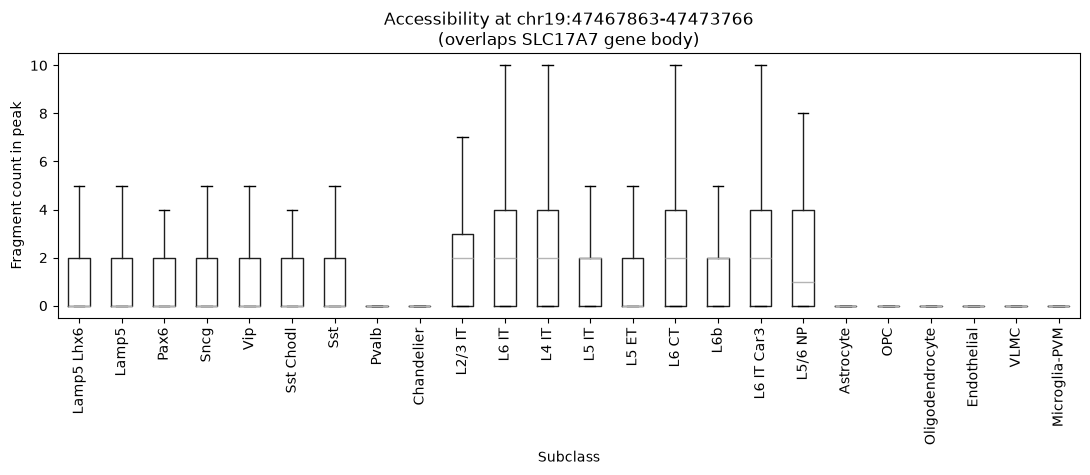

Subclass
L6 IT              2.389
L6 CT              2.101
L6b                2.057
L4 IT              1.998
L2/3 IT            1.945
L6 IT Car3         1.932
L5 IT              1.899
L5 ET              1.846
L5/6 NP            1.826
Lamp5 Lhx6         1.487
Pax6               1.358
Sst Chodl          1.182
Lamp5              1.167
Vip                1.112
Sst                1.037
Sncg               0.876
Pvalb              0.628
Chandelier         0.587
OPC                0.319
Astrocyte          0.138
Oligodendrocyte    0.135
Microglia-PVM      0.072
VLMC               0.055
Endothelial        0.000
Name: slc17a7_peak_accessibility, dtype: float32


In [7]:
subclass_order = (
    atac.obs.groupby("Subclass", observed=True)["slc17a7_peak_accessibility"]
    .mean()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(11, 5))
atac.obs.boxplot(
    column="slc17a7_peak_accessibility", by="Subclass", ax=ax,
    rot=90, grid=False, showfliers=False,
)
ax.set_title(f"Accessibility at {target_peak}\n(overlaps SLC17A7 gene body)")
ax.set_ylabel("Fragment count in peak")
plt.suptitle("")
plt.tight_layout()
plt.show()

print(atac.obs.groupby("Subclass", observed=True)["slc17a7_peak_accessibility"].mean().sort_values(ascending=False).round(3))

You should see meaningfully higher accessibility in the excitatory (glutamatergic,
"L*" prefixed) subclasses compared to inhibitory subtypes (Vip, Pvalb, Sst,
Lamp5...) and non-neuronal glia (Astrocyte, Oligodendrocyte, OPC,
Microglia-PVM) — a real, if simple, demonstration that ATAC accessibility
at a gene locus tracks that gene's cell-type-specific expression, exactly
as the biology predicts.

## What we did *not* do here (and why)

This notebook deliberately stops at "one peak, one gene, eyeballed
per-subclass." A proper single-cell ATAC pipeline — which the companion
`sea-ad-multiome-cortex` R/Signac project carries out — involves:
- **LSI (Latent Semantic Indexing)** instead of PCA for dimensionality
  reduction, because ATAC data has different statistical properties
  (extremely sparse, near-binary per peak) than RNA counts.
- **Peak calling** from scratch (MACS2) rather than relying on
  pre-supplied peak sets.
- **Gene activity scores** — aggregating accessibility across a gene's
  promoter and body into a single per-gene score comparable to RNA
  expression, rather than picking one peak by hand as we did here.
- **WNN (Weighted Nearest Neighbor) integration** — jointly clustering
  nuclei using both RNA and ATAC modalities at once (since these are
  paired multiome nuclei, both modalities are available for the same
  physical nucleus), weighting each modality by how informative it is
  per-nucleus.

All of that is real, substantial additional work — appropriate for a
dedicated project, not a bonus intro notebook. What you should take away
here is purely conceptual: what an accessibility matrix looks like, how it
differs structurally from a count matrix, and a first taste of how it
connects back to the RNA side.

## Recap

- ATAC data is nuclei x **peaks** (genomic intervals), not nuclei x genes —
  and typically has many more features than an RNA matrix.
- Values are **fragment counts**: how many sequenced DNA fragments from a
  nucleus overlapped a given peak, i.e. a proxy for how open that region of
  chromatin was in that nucleus.
- A peak overlapping a cell-type marker gene's body showed exactly the
  expected cell-type-specific accessibility pattern.
- Full multiome integration (LSI, gene activity scores, WNN) is
  substantially more work and is what the companion R/Signac project does.

## Homework

1. **A different marker.** Using the `peaks_in_region` function above, find
   peaks near **GAD1** (inhibitory marker, hg38 approximately
   `chr2:170,712,890-170,857,015`), plot accessibility of the peak with the
   best overlap across `Subclass`, and check whether it's elevated in
   inhibitory subclasses (Vip, Pvalb, Sst, Lamp5, etc.) as expected.

2. **Write the code yourself:** compute the *fraction of nuclei* with
   nonzero accessibility at `target_peak` (SLC17A7), split by whether the
   nucleus is an excitatory subclass or not. (Hint: you'll need to build an
   excitatory/non-excitatory label — reuse the `subclass_to_coarse`-style
   mapping idea from notebook 03.)

3. **Interpretation.** The accessibility values here are raw fragment
   counts, not normalized for each nucleus's total ATAC sequencing depth.
   How might that bias the boxplot comparison above, and what would you
   normalize by (think about what plays the role that `total_counts`
   played for RNA in notebook 02)?

4. **Open-ended.** Look at `atac.n_vars` (total peaks) versus the RNA
   data's `n_vars` (total genes) from notebook 00. Why do you think a
   typical ATAC feature set is roughly 5-6x larger than the gene set, given
   what a peak represents?

In [8]:
# Q1 — your code here

In [9]:
# Q2 — your code here

Q3 — your answer here

Q4 — your answer here